# SAM 2 — zero-shot leaf segmentation (notebook)

An interactive, read-it-top-to-bottom version of `run_sam2.py`.

It runs Meta's **Segment Anything 2** in *automatic* mode to segment everything
in the image, then keeps the **green, mid-sized** masks as candidate leaves.
No training or annotation needed — the weights auto-download from Hugging Face.

In [1]:
import os, sys, time

import torch
import matplotlib.pyplot as plt

# Make the repo's shared helpers importable (image IO, colour overlay, green test).
# This notebook lives in 2d_foundation/01_sam2, so the repo root is two levels up.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from shared.helper import load_image, overlay_masks, green_fraction, write_masks

## 1. Settings

Pick an input image, a model size, and the sampling density.

In [2]:
IMAGE = os.path.join(REPO_ROOT, "data/cvppp/images/A1/plant001_rgb.png")
MODEL_ID = "facebook/sam2.1-hiera-small"   # tiny / small fit ~6 GB; large may OOM
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
POINTS_PER_SIDE = 32                        # lower (e.g. 16) = faster, coarser

print("image :", IMAGE)
print("model :", MODEL_ID)
print("device:", DEVICE)

image : /home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/data/cvppp/images/A1/plant001_rgb.png
model : facebook/sam2.1-hiera-small
device: cuda


## 2. Build the SAM 2 automatic mask generator

Load the pretrained model once so we can reuse it. Weights download from Hugging
Face the first time.

In [3]:
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

mask_generator = SAM2AutomaticMaskGenerator.from_pretrained(
    MODEL_ID, device=DEVICE, points_per_side=POINTS_PER_SIDE,
)
print("SAM 2 ready.")

/home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/2d_foundation/01_sam2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SAM 2 ready.


## 3. Segment everything

SAM 2 places a grid of prompt points and returns one mask per object it finds —
leaves, but also pot, soil, and background. It has no concept of "leaf".

In [4]:
image = load_image(IMAGE)                     # (H, W, 3) RGB uint8

t0 = time.time()
with torch.inference_mode():
    anns = mask_generator.generate(image)     # class-agnostic: segments everything
print(f"SAM 2 found {len(anns)} raw masks in {time.time() - t0:.1f}s")

/home/marvin/shared/olive-leaves-disease-detection/leaf_segmenter/2d_foundation/01_sam2/.venv/lib/python3.14/site-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


SAM 2 found 11 raw masks in 4.7s


## 4. Keep the leaf-like masks

Because SAM 2 is class-agnostic, we filter its masks down to the ones that look
like foliage: **mid-sized** (not specks, not the whole background) and **mostly
green**.

In [5]:
MIN_GREEN = 0.5       # >= this fraction of green pixels
MIN_AREA  = 0.0005    # drop specks smaller than this fraction of the image
MAX_AREA  = 0.25      # drop background/pot bigger than this fraction

H, W = image.shape[:2]
total = H * W

leaves = []
for a in anns:
    mask = a["segmentation"].astype(bool)
    area = mask.sum()
    if area < MIN_AREA * total or area > MAX_AREA * total:
        continue                              # too small (noise) or too big (background)
    if green_fraction(image, mask) < MIN_GREEN:
        continue                              # not green enough to be foliage
    leaves.append(mask)

print(f"kept {len(leaves)} leaf masks (out of {len(anns)})")

kept 7 leaf masks (out of 11)


## 5. Visualise the result

Input on the left, coloured leaf masks on the right.

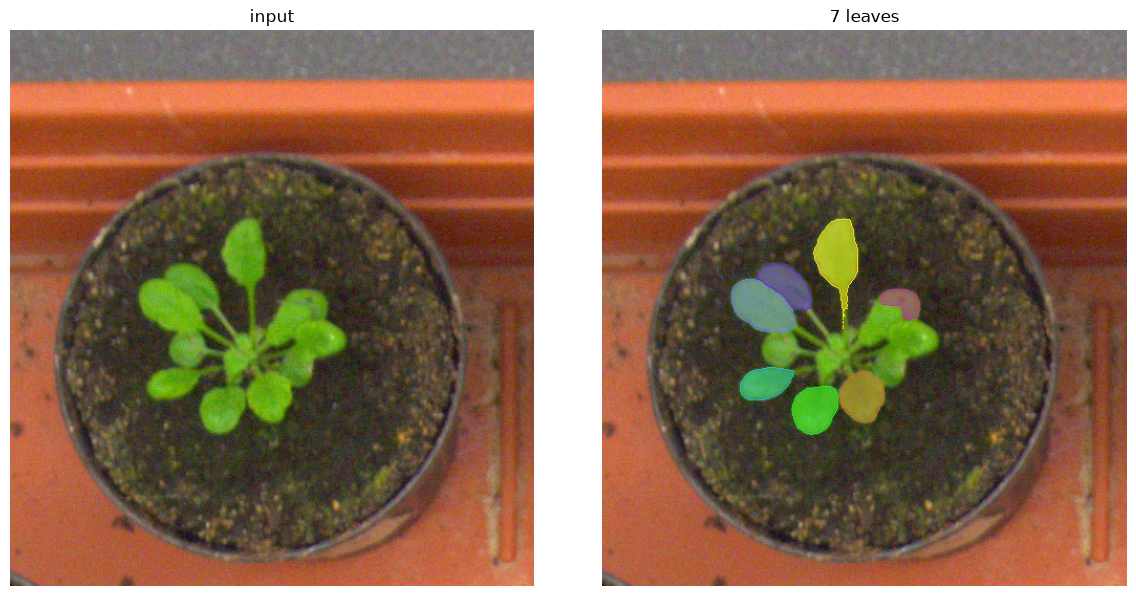

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("input")
ax[0].axis("off")
ax[1].imshow(overlay_masks(image, leaves))
ax[1].set_title(f"{len(leaves)} leaves")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## 6. (optional) Save binary masks for evaluation

Write one white-on-black PNG per leaf, full image size — exactly what
`eval/evaluate_leaf_segmentation.py` scores against the CVPPP ground truth
(SBD / FBD).

In [ ]:
out_dir = os.path.join("output", "notebook", "plant001_rgb_masks")
n = write_masks(leaves, out_dir, "plant001_rgb")
print(f"wrote {n} binary masks -> {out_dir}")